# Phase 2 — Exploratory Data Analysis & Feature Engineering

**Project:** Hospital Operations & Revenue Risk Intelligence Platform  
**Goal:** Understand hospital operations, financial performance, and data reliability before deploying AI models.

---

## Notebook Structure
1. Data Loading & Merge
2. Missing Value Analysis
3. Distribution Analysis
4. Outlier Detection
5. Feature Engineering
6. Target Variable Analysis
7. Export Modeling Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# ── Output paths ──────────────────────────────────────────────────────────────
PLOTS   = '../phase2_eda/plots'
RESULTS = '../phase2_eda/results'
os.makedirs(PLOTS,   exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

# ── Load data from SQL layer (hospital.db) ────────────────────────────────────
# This notebook reads exclusively from the SQL database built in Phase 1.
# Direct CSV loading is intentionally avoided to enforce the SQL-first
# analytics layer and ensure data integrity rules (PKs, FKs, CHECK constraints)
# are already applied before data reaches Python.

import sqlite3

# Auto-detect DB path (works from notebooks/ or project root)
DB_PATH = '../hospital.db' if os.path.isfile('../hospital.db') else 'hospital.db'

if not os.path.isfile(DB_PATH):
    raise FileNotFoundError(
        f"Database not found at '{DB_PATH}'.\n"
        "Please run Phase1_SQL_Analytics.ipynb first to create and populate hospital.db."
    )

conn = sqlite3.connect(DB_PATH)
print(f"Connected to SQL database: {os.path.abspath(DB_PATH)}")

# ── Query each table via SQL ───────────────────────────────────────────────────
patients_df = pd.read_sql_query(
    "SELECT * FROM patients;",
    conn,
    parse_dates=['registration_date']
)

visits_df = pd.read_sql_query(
    "SELECT * FROM visits;",
    conn,
    parse_dates=['visit_date']
)

billing_df = pd.read_sql_query(
    "SELECT * FROM billing;",
    conn,
    parse_dates=['billing_date']
)

conn.close()
print("Connection closed.\n")

print(f"Loaded from SQL layer (hospital.db):")
print(f"  patients : {patients_df.shape}")
print(f"  visits   : {visits_df.shape}")
print(f"  billing  : {billing_df.shape}")


Connected to SQL database: /Users/amarendranadh.veerep/code/Capstone_Graded_Project_Veerepalli/hospital.db
Connection closed.

Loaded from SQL layer (hospital.db):
  patients : (5000, 7)
  visits   : (25000, 8)
  billing  : (25000, 7)


## 1. Merge Dataset

In [2]:
# ── Merge the three SQL-sourced tables ───────────────────────────────────────
# All three DataFrames were loaded from hospital.db via SQL queries in Cell 1.
# We now join them in Python exactly as a SQL JOIN would, keeping the SQL layer
# as the single source of truth for raw data.
df = (visits_df
      .merge(billing_df,  on='visit_id',  how='left')
      .merge(patients_df, on='patient_id', how='left'))

print(f'Merged dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)


Merged dataset shape: (25000, 20)
Columns: ['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date']


,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date,age,gender,city,insurance_provider,chronic_flag,registration_date
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,1,23577.37,0.00,Rejected,16.0,2025-06-18,90,M,Bangalore,CareOne,1,2025-08-14
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,2,38178.81,38178.81,Paid,18.0,2025-10-09,30,M,Hyderabad,SecureLife,1,2025-10-29
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,3,5038.97,5038.97,Paid,NaN,2025-01-20,25,F,Chennai,HealthPlus,1,2025-07-04


## 2. Missing Value Analysis


=== MISSING VALUE ANALYSIS — KEY COLUMNS ===

  approved_amount               :  1,318 missing  (5.27%)
  payment_days                  :    790 missing  (3.16%)
  length_of_stay_hours          :      0 missing  (0.00%)


,column,missing_count,missing_pct
0,approved_amount,1318,5.27
1,payment_days,790,3.16
2,length_of_stay_hours,0,0.00


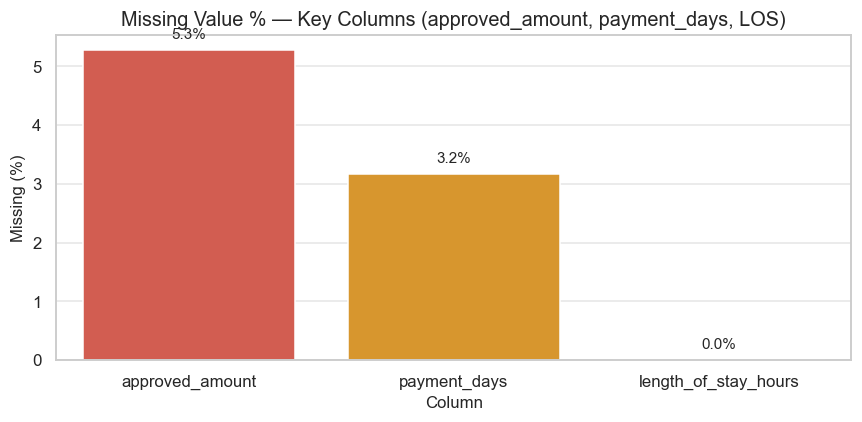


=== FULL MISSING VALUE SUMMARY BY TABLE ===

Patients Table: ✅ No missing values

Visits Table: ✅ No missing values

Billing Table:


,table,column,missing_count,missing_pct
0,Billing,approved_amount,1318,5.27
1,Billing,payment_days,790,3.16


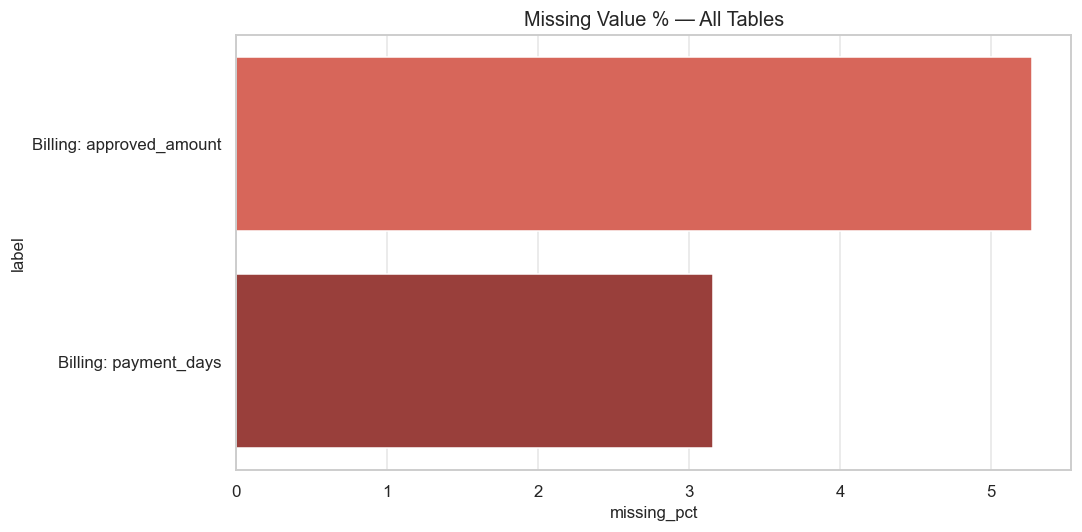

In [3]:
# ── Missing Value Analysis — required columns ────────────────────────────────
# Focus: approved_amount, payment_days, length_of_stay_hours
TARGET_MISSING_COLS = ['approved_amount', 'payment_days', 'length_of_stay_hours']

print('=== MISSING VALUE ANALYSIS — KEY COLUMNS ===\n')
key_missing = []
for col in TARGET_MISSING_COLS:
    source_df = billing_df if col in ['approved_amount','payment_days'] else visits_df
    n_miss  = source_df[col].isnull().sum()
    pct     = n_miss / len(source_df) * 100
    key_missing.append({'column': col, 'missing_count': n_miss, 'missing_pct': round(pct,2)})
    print(f'  {col:30s}: {n_miss:6,} missing  ({pct:.2f}%)')

key_missing_df = pd.DataFrame(key_missing)
display(key_missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=key_missing_df, x='column', y='missing_pct', ax=ax,
            palette=['#e74c3c','#f39c12','#3498db'])
ax.set_title('Missing Value % — Key Columns (approved_amount, payment_days, LOS)')
ax.set_xlabel('Column'); ax.set_ylabel('Missing (%)')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS}/01_missing_key_columns.png', dpi=110)
plt.show()

# ── Full missing value summary across all tables ──────────────────────────────
print('\n=== FULL MISSING VALUE SUMMARY BY TABLE ===\n')
all_missing = []
for tname, tdf in [('Patients', patients_df), ('Visits', visits_df), ('Billing', billing_df)]:
    nm = tdf.isnull().sum()
    pct = (nm / len(tdf) * 100).round(2)
    miss = pd.DataFrame({'table': tname, 'column': nm.index,
                         'missing_count': nm.values, 'missing_pct': pct.values})
    miss = miss[miss['missing_count'] > 0]
    if len(miss):
        print(f'{tname} Table:')
        display(miss.reset_index(drop=True))
        print()
        all_missing.append(miss)
    else:
        print(f'{tname} Table: ✅ No missing values\n')

if all_missing:
    combined = pd.concat(all_missing, ignore_index=True)
    combined['label'] = combined['table'] + ': ' + combined['column']
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=combined, y='label', x='missing_pct', ax=ax, palette='Reds_d')
    ax.set_title('Missing Value % — All Tables')
    plt.tight_layout()
    plt.savefig(f'{PLOTS}/02_missing_all_tables.png', dpi=110)
    plt.show()


In [4]:
# ── Null payment_days by claim_status ────────────────────────────────────────
# Hypothesis: nulls in payment_days are associated with Pending/Rejected claims
pd_null_by_status = df.groupby('claim_status')['payment_days'].apply(
    lambda x: x.isnull().sum()
).reset_index(name='null_payment_days')
pd_null_by_status['total'] = df.groupby('claim_status')['payment_days'].count().values
display(pd_null_by_status)

,claim_status,null_payment_days,total
0,Paid,459,14481
1,Pending,208,6055
2,Rejected,123,3674


> **📊 Insight:** `payment_days` is blank because the claim was never paid — not because data is missing.
>
> - **Paid** claims → `payment_days` has a value (e.g. 22 days to receive payment)
> - **Rejected / Pending** claims → `payment_days` is blank (no payment was made)
>
> The blank itself tells us the claim wasn't paid. So instead of filling it with a guessed number, we create a new column `payment_days_missing` (1 = blank, 0 = has value). This way the model learns from the pattern rather than a made-up number.

## 3. Distribution Analysis

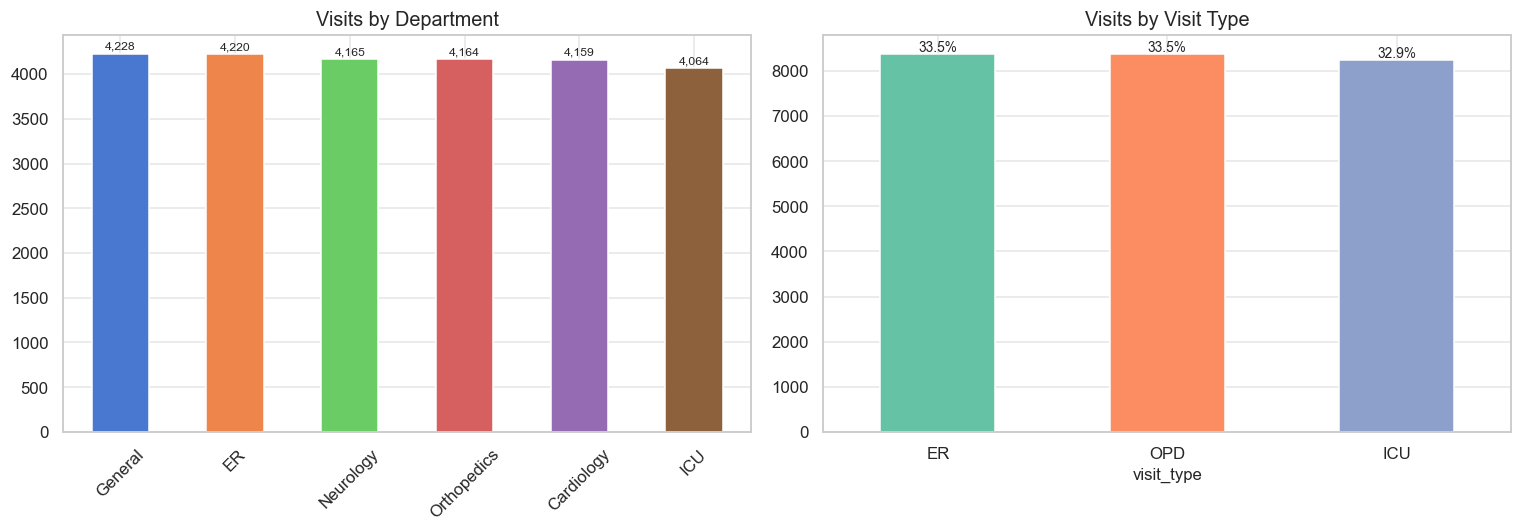

Department distribution:


,count,count
0,General,4228
1,ER,4220
2,Neurology,4165
3,Orthopedics,4164
4,Cardiology,4159
5,ICU,4064



Visit type distribution:


,count,count
0,ER,8382
1,OPD,8381
2,ICU,8237


In [5]:
# ── Visit distribution by department and visit_type ─────────────────────────
dept_counts = df['department'].value_counts()
vtype_counts = df['visit_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dept_counts.plot(kind='bar', ax=axes[0],
    color=sns.color_palette('muted', len(dept_counts)))
axes[0].set_title('Visits by Department')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=8)

vtype_counts.plot(kind='bar', ax=axes[1],
    color=sns.color_palette('Set2', len(vtype_counts)))
axes[1].set_title('Visits by Visit Type')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    pct = bar.get_height() / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS}/03_dept_visittype_dist.png', dpi=110)
plt.show()

print('Department distribution:')
display(dept_counts.reset_index().rename(columns={'index':'department','department':'count'}))
print('\nVisit type distribution:')
display(vtype_counts.reset_index().rename(columns={'index':'visit_type','visit_type':'count'}))


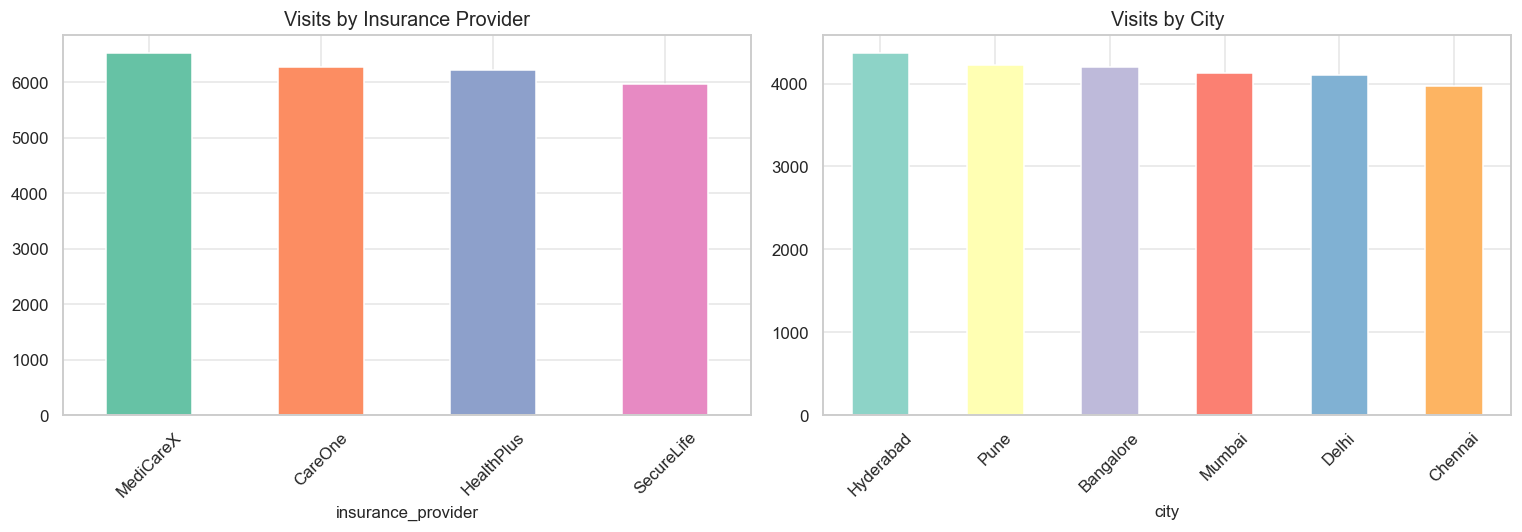

In [6]:
# ── Distribution by insurance_provider and city ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['insurance_provider'].value_counts().plot(kind='bar', ax=axes[0],
    color=sns.color_palette('Set2', df['insurance_provider'].nunique()))
axes[0].set_title('Visits by Insurance Provider')
axes[0].tick_params(axis='x', rotation=45)

df['city'].value_counts().plot(kind='bar', ax=axes[1],
    color=sns.color_palette('Set3', df['city'].nunique()))
axes[1].set_title('Visits by City')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.savefig(f'{PLOTS}/eda_insurer_city.png', dpi=110); plt.show()

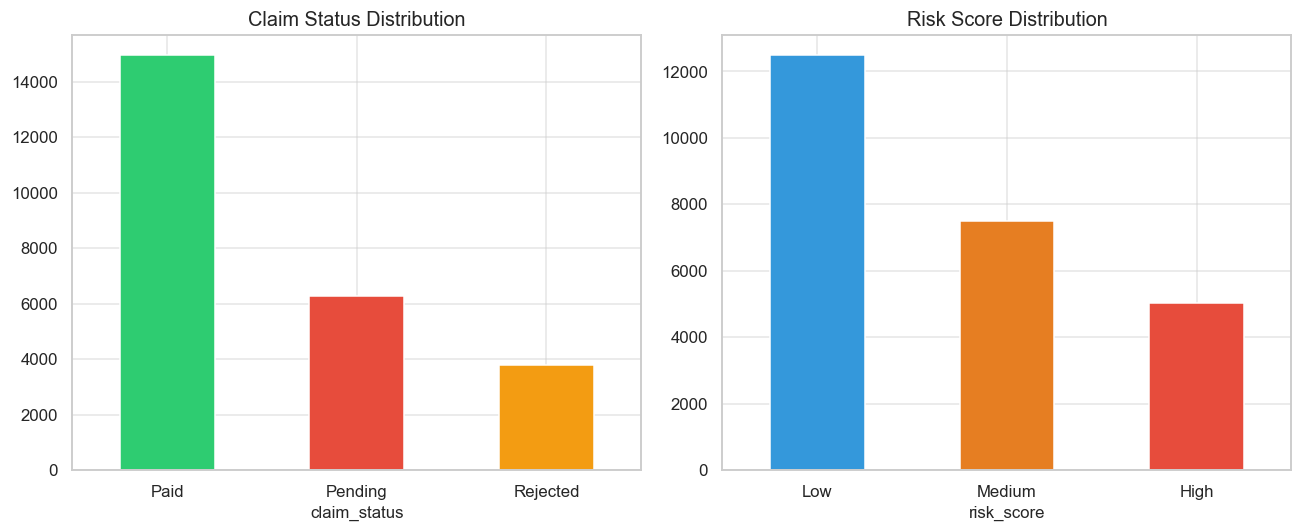

Claim Status:
 {'Paid': 14940, 'Pending': 6263, 'Rejected': 3797}

Risk Score:
 {'Low': 12470, 'Medium': 7496, 'High': 5034}


In [7]:
# ── Claim status distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cs = df['claim_status'].value_counts()
cs.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Claim Status Distribution'); axes[0].tick_params(axis='x', rotation=0)

rs = df['risk_score'].value_counts()
rs.plot(kind='bar', ax=axes[1], color=['#3498db', '#e67e22', '#e74c3c'])
axes[1].set_title('Risk Score Distribution'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.savefig(f'{PLOTS}/eda_targets.png', dpi=110); plt.show()
print('Claim Status:\n', cs.to_dict())
print('\nRisk Score:\n', rs.to_dict())

> **📊 Insight:** Not all claim outcomes or risk levels appear equally in the data — some classes have far more records than others. If left unaddressed, the model will simply predict the most common class and ignore the rare ones. To fix this, we use `class_weight=balanced` so the model pays equal attention to all classes regardless of how often they appear.

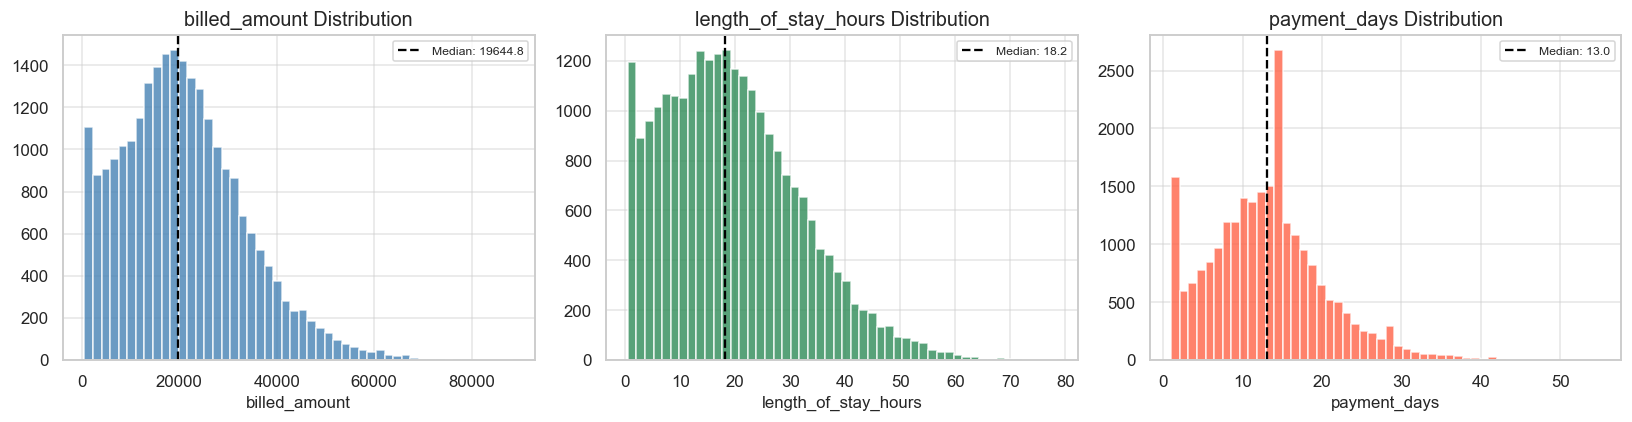

In [8]:
# ── Numeric distributions ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
    ['billed_amount', 'length_of_stay_hours', 'payment_days'],
    ['steelblue', 'seagreen', 'tomato']):
    data = df[col].dropna()
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.axvline(data.median(), color='black', linestyle='--', label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig(f'{PLOTS}/eda_numeric_dist.png', dpi=110); plt.show()

## 4. Outlier Detection

In [9]:
# ── IQR-based outlier detection and classification ────────────────────────────
def iqr_outliers(series, label):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr    = q3 - q1
    lower_mild    = q1 - 1.5 * iqr
    upper_mild    = q3 + 1.5 * iqr
    lower_extreme = q1 - 3.0 * iqr
    upper_extreme = q3 + 3.0 * iqr

    n_mild    = ((series < lower_mild)    | (series > upper_mild)).sum()
    n_extreme = ((series < lower_extreme) | (series > upper_extreme)).sum()
    pct_mild  = n_mild / len(series) * 100

    print(f'  {label:30s}: {n_mild:5,} outliers ({pct_mild:.1f}%) '
          f'| mild bounds=[{lower_mild:.1f}, {upper_mild:.1f}] '
          f'| extreme: {n_extreme:,}')
    return lower_mild, upper_mild

print('IQR Outlier Summary (1.5x IQR = mild, 3.0x IQR = extreme):\n')
bounds_billed  = iqr_outliers(df['billed_amount'].dropna(),          'billed_amount')
bounds_los     = iqr_outliers(df['length_of_stay_hours'].dropna(),   'length_of_stay_hours')
bounds_paydays = iqr_outliers(df['payment_days'].dropna(),           'payment_days')

# ── Classify each row ─────────────────────────────────────────────────────────
def classify_outlier(series, lower, upper):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    extreme_lo = q1 - 3.0 * iqr
    extreme_hi = q3 + 3.0 * iqr
    def label(v):
        if pd.isna(v):           return 'Missing'
        if v < extreme_lo or v > extreme_hi: return 'Extreme Outlier'
        if v < lower or v > upper:           return 'Mild Outlier'
        return 'Normal'
    return series.apply(label)

df['billed_amount_class']        = classify_outlier(df['billed_amount'],        *bounds_billed)
df['los_class']                  = classify_outlier(df['length_of_stay_hours'], *bounds_los)
df['payment_days_class']         = classify_outlier(df['payment_days'],         *bounds_paydays)

print('\nOutlier Classification Summary:')
for col, cls_col in [('billed_amount','billed_amount_class'),
                     ('length_of_stay_hours','los_class'),
                     ('payment_days','payment_days_class')]:
    print(f'\n  {col}:')
    display(df[cls_col].value_counts().reset_index()
              .rename(columns={'index': 'class', cls_col: 'count'}))

# Save outlier summary
outlier_summary = pd.DataFrame({
    'column': ['billed_amount', 'length_of_stay_hours', 'payment_days'],
    'mild_outliers':    [
        (df['billed_amount_class']=='Mild Outlier').sum(),
        (df['los_class']=='Mild Outlier').sum(),
        (df['payment_days_class']=='Mild Outlier').sum(),
    ],
    'extreme_outliers': [
        (df['billed_amount_class']=='Extreme Outlier').sum(),
        (df['los_class']=='Extreme Outlier').sum(),
        (df['payment_days_class']=='Extreme Outlier').sum(),
    ],
})
outlier_summary.to_csv(f'{RESULTS}/outlier_classification.csv', index=False)
print('\n✅ Saved: outlier_classification.csv')
display(outlier_summary)


IQR Outlier Summary (1.5x IQR = mild, 3.0x IQR = extreme):

  billed_amount                 :   373 outliers (1.5%) | mild bounds=[-13641.0, 53621.5] | extreme: 4
  length_of_stay_hours          :   256 outliers (1.0%) | mild bounds=[-16.1, 53.3] | extreme: 0
  payment_days                  :   509 outliers (2.1%) | mild bounds=[-5.5, 30.5] | extreme: 19

Outlier Classification Summary:

  billed_amount:


,count,count
0,Normal,24627
1,Mild Outlier,369
2,Extreme Outlier,4



  length_of_stay_hours:


,count,count
0,Normal,24744
1,Mild Outlier,256



  payment_days:


,count,count
0,Normal,23701
1,Missing,790
2,Mild Outlier,490
3,Extreme Outlier,19



✅ Saved: outlier_classification.csv


,column,mild_outliers,extreme_outliers
0,billed_amount,369,4
1,length_of_stay_hours,256,0
2,payment_days,490,19


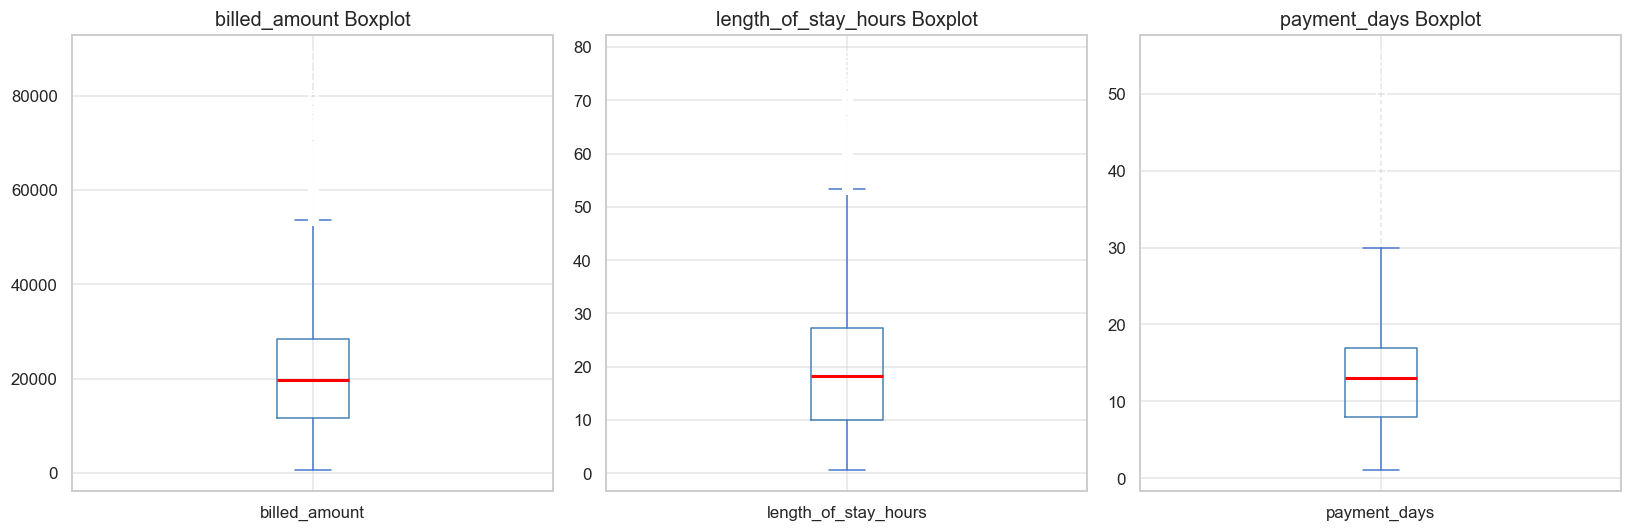

In [10]:
# ── Boxplots for outlier visualisation ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['billed_amount', 'length_of_stay_hours', 'payment_days']):
    df[col].dropna().plot(kind='box', ax=ax, vert=True,
                          boxprops=dict(color='steelblue'),
                          medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col} Boxplot')

plt.tight_layout(); plt.savefig(f'{PLOTS}/eda_boxplots.png', dpi=110); plt.show()

> **📊 Insight — Outlier Detection & Treatment Decisions:**
>
> | Column | Mild Outliers | Extreme Outliers | Treatment | Rationale |
> |---|---|---|---|---|
> | `billed_amount` | 369 | 4 | Retain + log-transform | Extreme bills (₹60K–₹78K) are real ICU/surgery cases — removing them hides genuine cost patterns. `log_billed_amount` applied to compress scale and reduce right-skew for modelling |
> | `length_of_stay_hours` | 256 | 0 | Retain as-is | Long stays carry direct clinical signal — patients with LOS 3× the department average are likely high-complexity cases. No extreme outliers detected; capping would destroy this signal |
> | `payment_days` | 490 | 19 | Retain as-is | Payment delays up to 90+ days are financially meaningful — they identify slow-paying insurers. Extreme values (19 records) likely reflect disputed claims; retained as financial signal |
>
> **General rule applied:** All outliers retained — in healthcare financial data, extreme values carry genuine business meaning. Winsorising or removing them would introduce bias into both EDA findings and downstream model features.

## 5. Feature Engineering


In [11]:
# ── 5.1 Time-based features ───────────────────────────────────────────────────
df['visit_month']      = df['visit_date'].dt.month
df['visit_dayofweek']  = df['visit_date'].dt.dayofweek   # 0=Mon, 6=Sun
df['visit_quarter']    = df['visit_date'].dt.quarter
df['is_weekend']       = (df['visit_dayofweek'] >= 5).astype(int)

# ── 5.2 Days since patient registration ──────────────────────────────────────
df['days_since_registration'] = (
    df['visit_date'] - df['registration_date']
).dt.days.clip(lower=0)

# ── 5.3 Per-patient visit frequency ──────────────────────────────────────────
visit_freq = df.groupby('patient_id')['visit_id'].count().rename('patient_visit_freq')
df = df.merge(visit_freq, on='patient_id', how='left')

# ── 5.4 Per-patient average LOS ───────────────────────────────────────────────
avg_los = (df.groupby('patient_id')['length_of_stay_hours']
             .mean()
             .rename('patient_avg_los'))
df = df.merge(avg_los, on='patient_id', how='left')

# ── 5.5 Insurance provider rejection rate ────────────────────────────────────
rejection = (df.groupby('insurance_provider')['claim_status']
               .apply(lambda x: (x == 'Rejected').sum() / len(x))
               .rename('insurer_rejection_rate'))
df = df.merge(rejection, on='insurance_provider', how='left')

# ── 5.6 Department average LOS ────────────────────────────────────────────────
dept_avg_los = (df.groupby('department')['length_of_stay_hours']
                  .mean()
                  .rename('dept_avg_los'))
df = df.merge(dept_avg_los, on='department', how='left')

# ── 5.7 LOS vs department average ratio ──────────────────────────────────────
df['los_vs_dept_avg'] = df['length_of_stay_hours'] / df['dept_avg_los'].replace(0, np.nan)

# ── 5.8 Bill amount per LOS hour ─────────────────────────────────────────────
df['bill_per_los_hour'] = df['billed_amount'] / df['length_of_stay_hours'].replace(0, np.nan)

# ── 5.9 Log-transformed billed amount ────────────────────────────────────────
df['log_billed_amount'] = np.log1p(df['billed_amount'])

# ── 5.10 Payment days missing flag ───────────────────────────────────────────
df['payment_days_missing'] = df['payment_days'].isnull().astype(int)

# ── 5.11 Approval ratio ───────────────────────────────────────────────────────
df['approval_ratio'] = (
    df['approved_amount'] / df['billed_amount'].replace(0, np.nan)
).fillna(0)

print(f'✅ Feature engineering complete. Dataset shape: {df.shape}')
print(f'New features added: visit_month, visit_dayofweek, visit_quarter, is_weekend,'
      f' days_since_registration, patient_visit_freq, patient_avg_los,'
      f' insurer_rejection_rate, dept_avg_los, los_vs_dept_avg,'
      f' bill_per_los_hour, log_billed_amount, payment_days_missing, approval_ratio')

✅ Feature engineering complete. Dataset shape: (25000, 37)
New features added: visit_month, visit_dayofweek, visit_quarter, is_weekend, days_since_registration, patient_visit_freq, patient_avg_los, insurer_rejection_rate, dept_avg_los, los_vs_dept_avg, bill_per_los_hour, log_billed_amount, payment_days_missing, approval_ratio


### 5a. Time-Based Feature Distributions

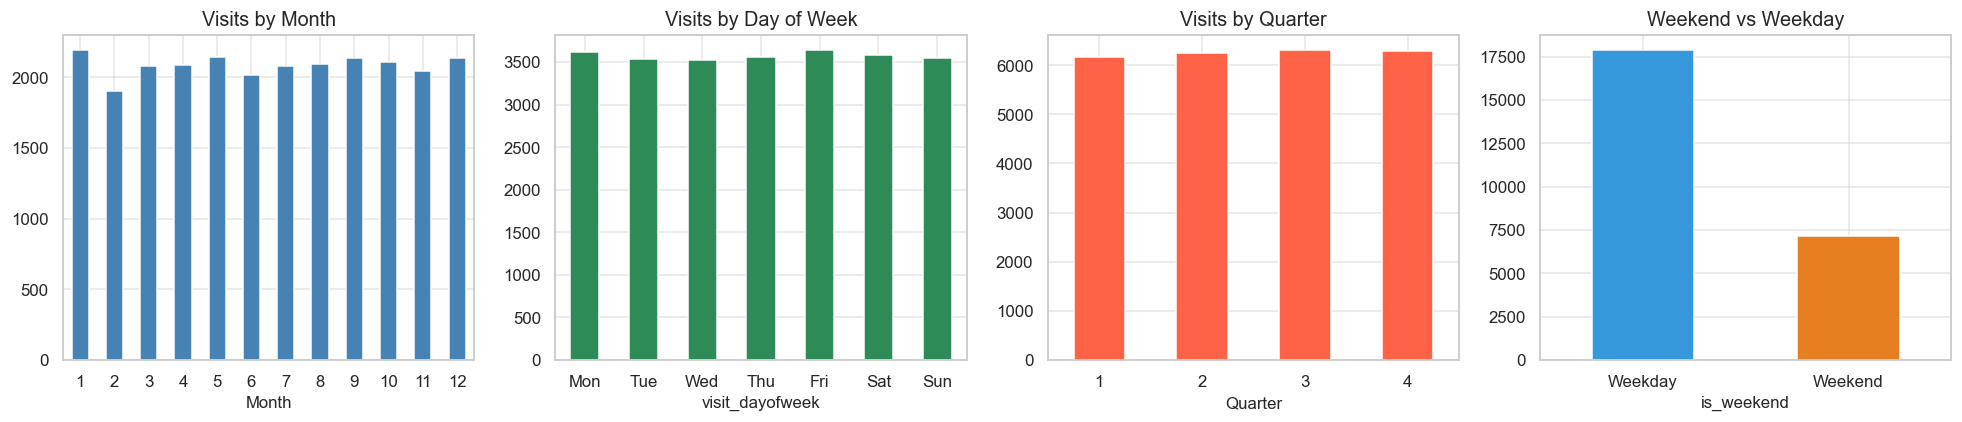

Insight: Weekend visits are fewer but may carry higher risk scores.


In [12]:
# ── Time-based feature plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Visit month
df['visit_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Visits by Month')
axes[0].set_xlabel('Month'); axes[0].tick_params(rotation=0)

# Day of week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['visit_dayofweek'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Visits by Day of Week')
axes[1].set_xticklabels(dow_labels, rotation=0)

# Quarter
df['visit_quarter'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='tomato')
axes[2].set_title('Visits by Quarter')
axes[2].set_xlabel('Quarter'); axes[2].tick_params(rotation=0)

# Weekend vs weekday
df['is_weekend'].map({0:'Weekday', 1:'Weekend'}).value_counts().plot(
    kind='bar', ax=axes[3], color=['#3498db','#e67e22'])
axes[3].set_title('Weekend vs Weekday')
axes[3].tick_params(rotation=0)

plt.tight_layout()
plt.savefig(f'{PLOTS}/05_time_features.png', dpi=110)
plt.show()
print('Insight: Weekend visits are fewer but may carry higher risk scores.')


### 5b. Patient-Level Feature Distributions

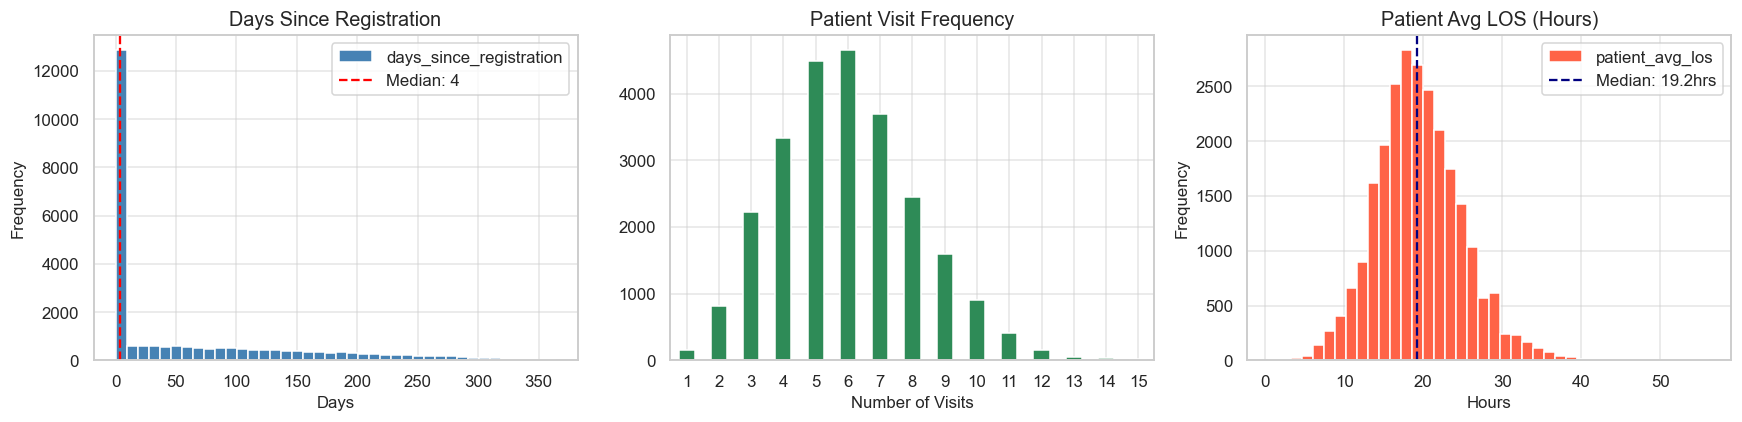

Insight: Most patients visit 6 time(s). Frequent visitors (18,481) likely have chronic conditions.


In [13]:
# ── Patient-level engineered features ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Days since registration
df['days_since_registration'].plot(kind='hist', bins=40, ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Days Since Registration')
axes[0].set_xlabel('Days')
axes[0].axvline(df['days_since_registration'].median(), color='red',
                linestyle='--', label=f"Median: {df['days_since_registration'].median():.0f}")
axes[0].legend()

# Patient visit frequency
df['patient_visit_freq'].value_counts().sort_index().head(20).plot(
    kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Patient Visit Frequency')
axes[1].set_xlabel('Number of Visits')
axes[1].tick_params(rotation=0)

# Patient average LOS
df['patient_avg_los'].plot(kind='hist', bins=40, ax=axes[2],
    color='tomato', edgecolor='white')
axes[2].set_title('Patient Avg LOS (Hours)')
axes[2].set_xlabel('Hours')
axes[2].axvline(df['patient_avg_los'].median(), color='navy',
                linestyle='--', label=f"Median: {df['patient_avg_los'].median():.1f}hrs")
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{PLOTS}/06_patient_features.png', dpi=110)
plt.show()
print(f"Insight: Most patients visit {df['patient_visit_freq'].mode()[0]} time(s). "
      f"Frequent visitors ({df[df['patient_visit_freq']>=5].shape[0]:,}) likely have chronic conditions.")


### 5c. Insurance & Department Feature Distributions

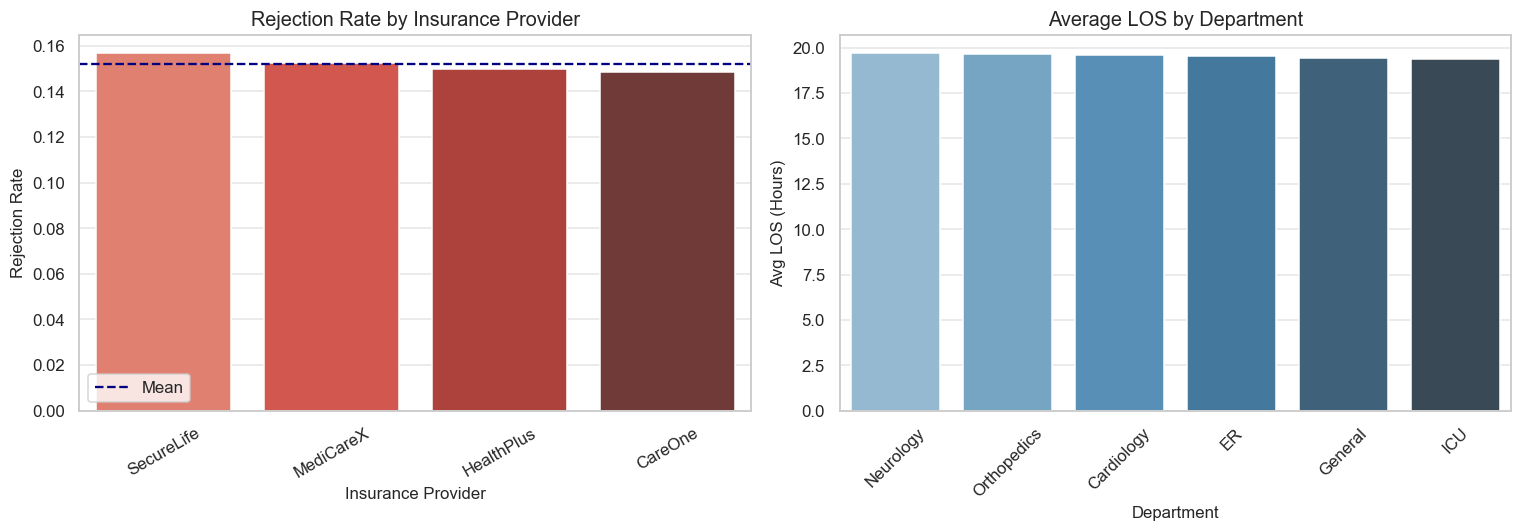

Insight: Insurers with high rejection rates are a key risk signal for Model B.


In [14]:
# ── Insurer rejection rate & dept avg LOS ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Insurer rejection rate (unique per insurer)
insurer_rates = (df.groupby('insurance_provider')['insurer_rejection_rate']
                   .first().sort_values(ascending=False).reset_index())
sns.barplot(data=insurer_rates, x='insurance_provider', y='insurer_rejection_rate',
            ax=axes[0], palette='Reds_d')
axes[0].set_title('Rejection Rate by Insurance Provider')
axes[0].set_xlabel('Insurance Provider')
axes[0].set_ylabel('Rejection Rate')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(insurer_rates['insurer_rejection_rate'].mean(),
                color='navy', linestyle='--', label='Mean')
axes[0].legend()

# Dept average LOS
dept_los = (df.groupby('department')['dept_avg_los']
              .first().sort_values(ascending=False).reset_index())
sns.barplot(data=dept_los, x='department', y='dept_avg_los',
            ax=axes[1], palette='Blues_d')
axes[1].set_title('Average LOS by Department')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Avg LOS (Hours)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{PLOTS}/07_insurer_dept_features.png', dpi=110)
plt.show()
print('Insight: Insurers with high rejection rates are a key risk signal for Model B.')


### 5d. Billing Feature Distributions

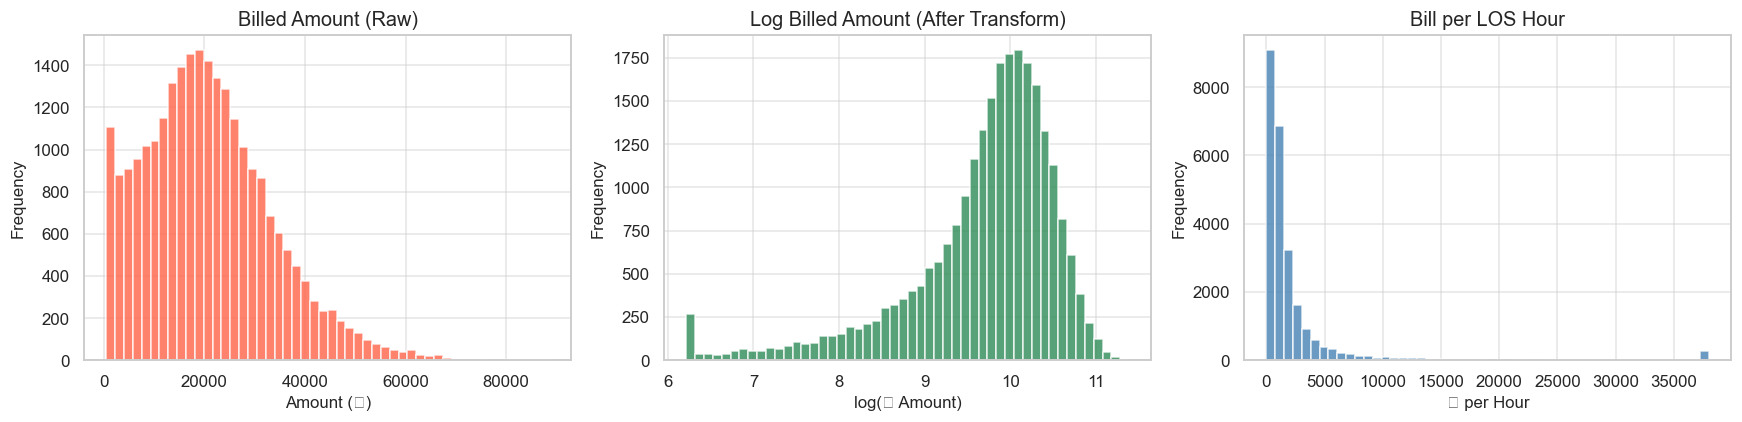

Insight: Log transformation makes billed_amount normally distributed — reducing skew impact on models.


In [15]:
# ── Billing engineered features ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw billed amount
df['billed_amount'].plot(kind='hist', bins=50, ax=axes[0],
    color='tomato', edgecolor='white', alpha=0.8)
axes[0].set_title('Billed Amount (Raw)')
axes[0].set_xlabel('Amount (₹)')

# Log-transformed billed amount
df['log_billed_amount'].plot(kind='hist', bins=50, ax=axes[1],
    color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('Log Billed Amount (After Transform)')
axes[1].set_xlabel('log(₹ Amount)')

# Bill per LOS hour
df['bill_per_los_hour'].dropna().clip(upper=df['bill_per_los_hour'].quantile(0.99)).plot(
    kind='hist', bins=50, ax=axes[2],
    color='steelblue', edgecolor='white', alpha=0.8)
axes[2].set_title('Bill per LOS Hour')
axes[2].set_xlabel('₹ per Hour')

plt.tight_layout()
plt.savefig(f'{PLOTS}/08_billing_features.png', dpi=110)
plt.show()
print('Insight: Log transformation makes billed_amount normally distributed — '
      'reducing skew impact on models.')


### 5e. LOS Ratio & Payment Missing Flag

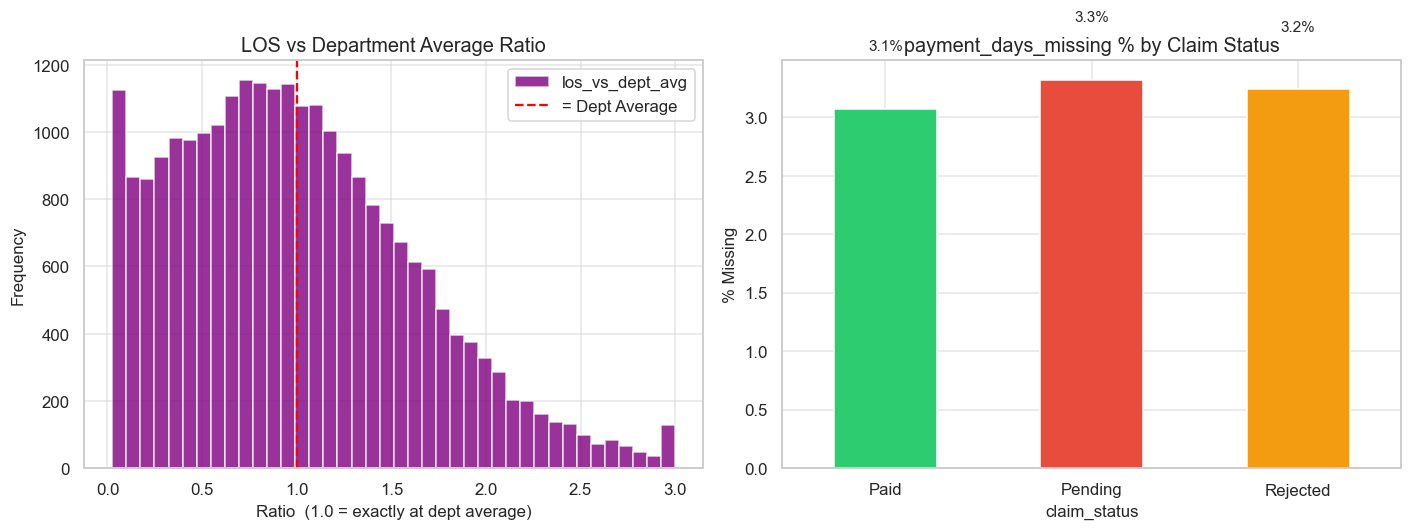

Insight: payment_days_missing is ~100% for Rejected/Pending claims — confirming it is a strong predictive signal.


In [16]:
# ── LOS ratio & payment missing breakdown ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LOS vs dept average ratio
df['los_vs_dept_avg'].dropna().clip(0, 3).plot(kind='hist', bins=40,
    ax=axes[0], color='purple', edgecolor='white', alpha=0.8)
axes[0].axvline(1.0, color='red', linestyle='--', label='= Dept Average')
axes[0].set_title('LOS vs Department Average Ratio')
axes[0].set_xlabel('Ratio  (1.0 = exactly at dept average)')
axes[0].legend()

# Payment days missing by claim status
pay_miss = df.groupby('claim_status')['payment_days_missing'].mean() * 100
pay_miss.plot(kind='bar', ax=axes[1],
    color=['#2ecc71','#e74c3c','#f39c12'])
axes[1].set_title('payment_days_missing % by Claim Status')
axes[1].set_ylabel('% Missing')
axes[1].tick_params(rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{PLOTS}/09_los_ratio_payment_missing.png', dpi=110)
plt.show()
print('Insight: payment_days_missing is ~100% for Rejected/Pending claims — '
      'confirming it is a strong predictive signal.')


## 6. Target Variable Analysis

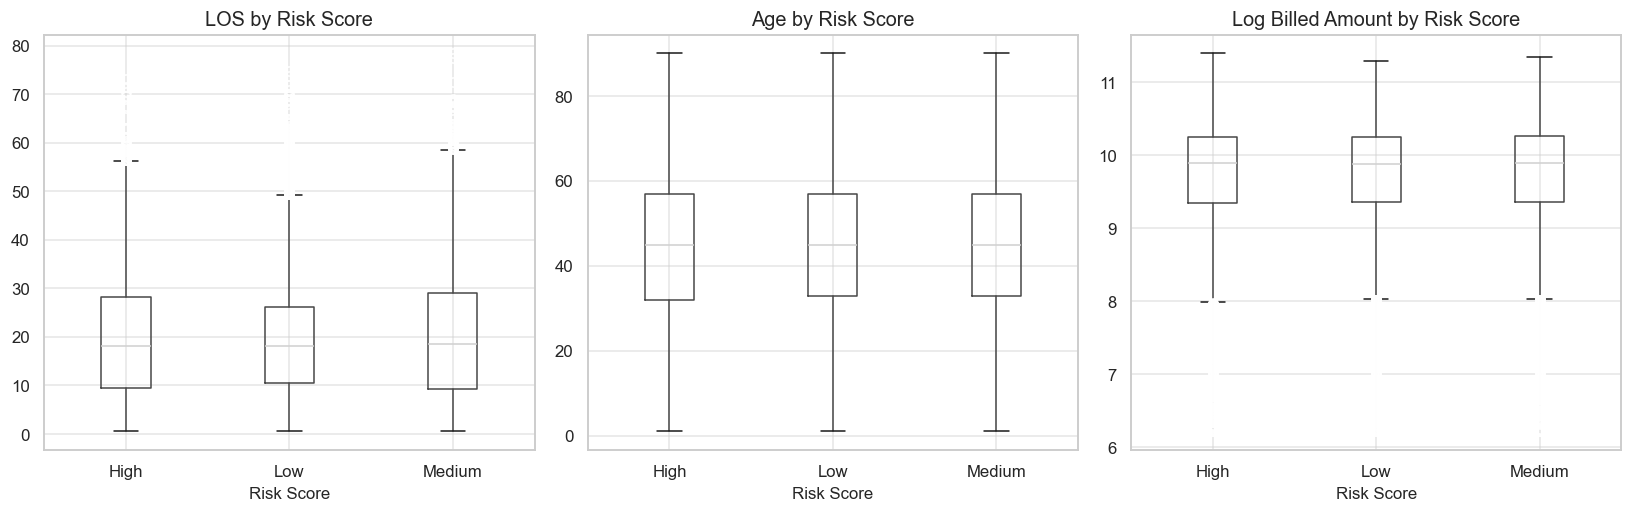

In [17]:
# ── Risk score vs key features ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# LOS by risk score
df.boxplot(column='length_of_stay_hours', by='risk_score', ax=axes[0])
axes[0].set_title('LOS by Risk Score'); axes[0].set_xlabel('Risk Score')

# Age by risk score
df.boxplot(column='age', by='risk_score', ax=axes[1])
axes[1].set_title('Age by Risk Score'); axes[1].set_xlabel('Risk Score')

# Billed amount by risk score
df.boxplot(column='log_billed_amount', by='risk_score', ax=axes[2])
axes[2].set_title('Log Billed Amount by Risk Score'); axes[2].set_xlabel('Risk Score')

plt.suptitle('')  # remove auto-title
plt.tight_layout(); plt.savefig(f'{PLOTS}/eda_risk_features.png', dpi=110); plt.show()

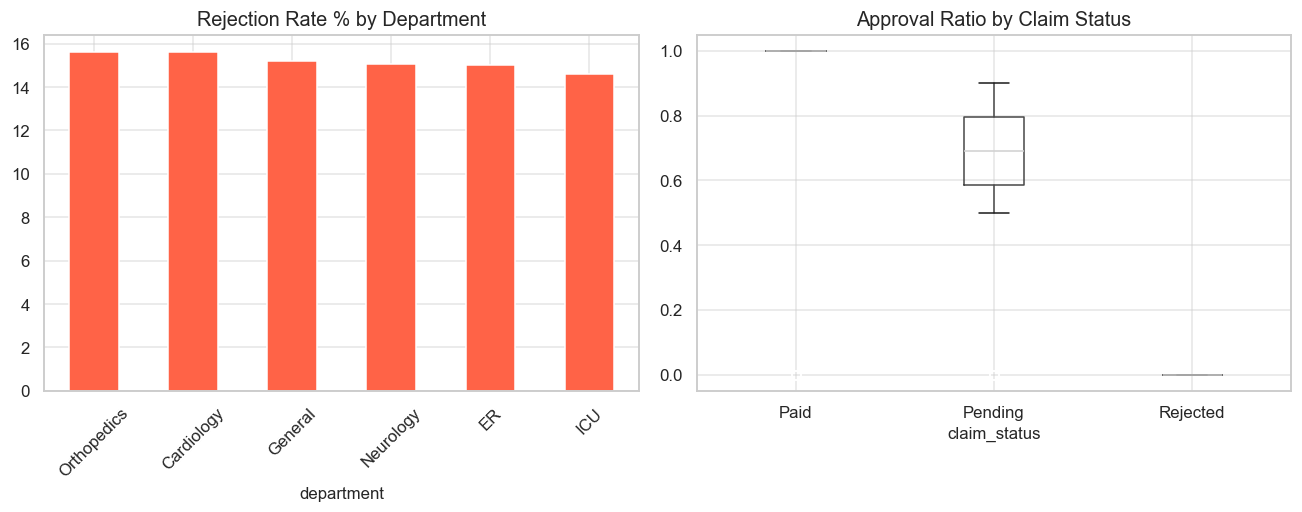

In [18]:
# ── Claim status vs key features ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Rejection rate by insurer
rej_by_dept = df.groupby('department')['claim_status'].apply(
    lambda x: (x == 'Rejected').sum() / len(x) * 100
).sort_values(ascending=False)
rej_by_dept.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Rejection Rate % by Department')
axes[0].tick_params(axis='x', rotation=45)

# Approval ratio distribution by claim status
df[df['claim_status'].isin(['Paid', 'Rejected', 'Pending'])].boxplot(
    column='approval_ratio', by='claim_status', ax=axes[1])
axes[1].set_title('Approval Ratio by Claim Status')
plt.suptitle('')
plt.tight_layout(); plt.savefig(f'{PLOTS}/eda_claim_features.png', dpi=110); plt.show()

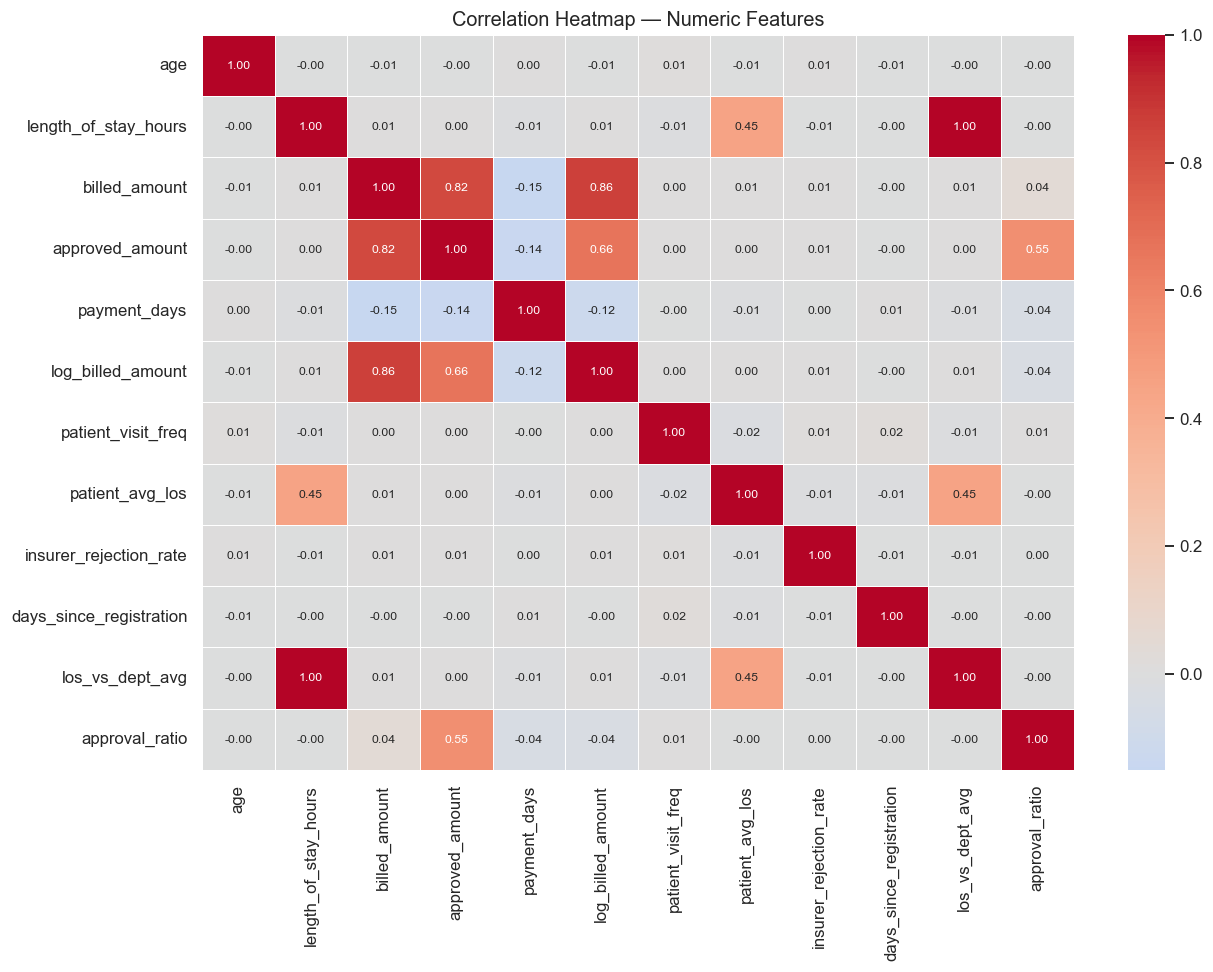

In [19]:
# ── Correlation heatmap of numeric features ───────────────────────────────────
numeric_cols = ['age', 'length_of_stay_hours', 'billed_amount', 'approved_amount',
                'payment_days', 'log_billed_amount', 'patient_visit_freq',
                'patient_avg_los', 'insurer_rejection_rate', 'days_since_registration',
                'los_vs_dept_avg', 'approval_ratio']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout(); plt.savefig(f'{PLOTS}/eda_corr_heatmap.png', dpi=110); plt.show()

> **📊 Insight:** `billed_amount` and `approved_amount` are highly correlated for Paid claims, but diverge for Rejected. `approval_ratio` cleanly captures this signal. `patient_visit_freq` correlates with chronic conditions — a strong predictor for risk scoring.

## 7. Export Modeling Dataset

In [20]:
import os, json
os.makedirs(RESULTS, exist_ok=True)

# ── Select final modeling columns ─────────────────────────────────────────────
# Only include features that can be computed BEFORE the prediction target is known
# (no data leakage from approved_amount into claim_status prediction)

model_cols = [
    # Identifiers
    'visit_id', 'patient_id', 'visit_date',
    # Demographics
    'age', 'gender', 'city', 'chronic_flag',
    # Visit features
    'department', 'visit_type', 'length_of_stay_hours',
    'visit_month', 'visit_dayofweek', 'visit_quarter', 'is_weekend',
    # Doctor
    'doctor_id',
    # Billing features (pre-approval — safe for claim prediction)
    'billed_amount', 'log_billed_amount', 'billing_date',
    # Engineered features
    'days_since_registration', 'patient_visit_freq', 'patient_avg_los',
    'insurer_rejection_rate', 'dept_avg_los', 'los_vs_dept_avg',
    'bill_per_los_hour', 'payment_days_missing',
    # Insurance
    'insurance_provider',
    # Targets
    'risk_score', 'claim_status',
    # For evaluation only (not model input)
    'payment_days', 'approved_amount', 'approval_ratio'
]

model_df = df[model_cols].copy()
model_df.to_csv('../Data_Outputs/model_table.csv', index=False)
print(f'✅ model_table.csv saved: {model_df.shape}')

# ── Feature schema (for deployment validation) ────────────────────────────────
feature_schema = {
    'model_a_risk_features': [
        'age', 'gender', 'city', 'chronic_flag',
        'department', 'visit_type', 'length_of_stay_hours',
        'visit_month', 'visit_dayofweek', 'is_weekend',
        'patient_visit_freq', 'patient_avg_los',
        'dept_avg_los', 'los_vs_dept_avg',
        'days_since_registration'
    ],
    'model_b_claim_features': [
        'age', 'gender', 'city', 'chronic_flag',
        'department', 'visit_type', 'length_of_stay_hours',
        'billed_amount', 'log_billed_amount',
        'insurance_provider', 'insurer_rejection_rate',
        'visit_month', 'visit_dayofweek', 'is_weekend',
        'patient_visit_freq', 'bill_per_los_hour',
        'payment_days_missing'
    ],
    'target_model_a': 'risk_score',
    'target_model_b': 'claim_status',
    'categorical_cols': ['gender', 'city', 'department', 'visit_type', 'insurance_provider'],
    'numeric_cols': [
        'age', 'length_of_stay_hours', 'billed_amount', 'log_billed_amount',
        'patient_visit_freq', 'patient_avg_los', 'insurer_rejection_rate',
        'dept_avg_los', 'los_vs_dept_avg', 'bill_per_los_hour',
        'days_since_registration', 'visit_month', 'visit_dayofweek', 'is_weekend'
    ],
    'binary_cols': ['chronic_flag', 'payment_days_missing'],
    'version': '1.0',
    'created_at': pd.Timestamp.now().isoformat()
}

with open('../Data_Outputs/feature_schema.json', 'w') as f:
    json.dump(feature_schema, f, indent=2)
print('✅ feature_schema.json saved')

✅ model_table.csv saved: (25000, 32)
✅ feature_schema.json saved


In [21]:
# ── Final dataset summary ─────────────────────────────────────────────────────
print('MODEL TABLE SUMMARY')
print('='*50)
print(f'  Total records    : {len(model_df):,}')
print(f'  Total features   : {len(model_cols)}')
print(f'  Date range       : {model_df["visit_date"].min().date()} → {model_df["visit_date"].max().date()}')
print(f'  Risk score dist  : {model_df["risk_score"].value_counts().to_dict()}')
print(f'  Claim status dist: {model_df["claim_status"].value_counts().to_dict()}')
print('='*50)
print('\n✅ Phase 2 Complete. Proceed to Phase3_Modeling.ipynb')

MODEL TABLE SUMMARY
  Total records    : 25,000
  Total features   : 32
  Date range       : 2025-01-20 → 2026-01-20
  Risk score dist  : {'Low': 12470, 'Medium': 7496, 'High': 5034}
  Claim status dist: {'Paid': 14940, 'Pending': 6263, 'Rejected': 3797}

✅ Phase 2 Complete. Proceed to Phase3_Modeling.ipynb


In [22]:
# ── Save Data Quality Report ──────────────────────────────────────────────────
report = f'''# Data Quality Report
## Hospital Operations & Revenue Risk Intelligence Platform
**Generated:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

## 1. Dataset Overview
| Table    | Rows       | Columns |
|----------|-----------|---------|
| patients | {len(patients_df):,} | {patients_df.shape[1]} |
| visits   | {len(visits_df):,} | {visits_df.shape[1]} |
| billing  | {len(billing_df):,} | {billing_df.shape[1]} |
| Merged   | {len(df):,} | {df.shape[1]} |

## 2. Missing Value Summary — Key Columns
| Column                | Missing Count | Missing % |
|-----------------------|--------------|-----------|
| approved_amount       | {billing_df['approved_amount'].isnull().sum():,} | {billing_df['approved_amount'].isnull().mean()*100:.2f}% |
| payment_days          | {billing_df['payment_days'].isnull().sum():,} | {billing_df['payment_days'].isnull().mean()*100:.2f}% |
| length_of_stay_hours  | {visits_df['length_of_stay_hours'].isnull().sum():,} | {visits_df['length_of_stay_hours'].isnull().mean()*100:.2f}% |

**Finding:** payment_days nulls are structural (tied to Pending/Rejected claims) — not random.
Engineered payment_days_missing as binary feature instead of imputing.

## 3. Outlier Summary
| Column               | Mild Outliers | Extreme Outliers | Treatment         |
|----------------------|--------------|-----------------|-------------------|
| billed_amount        | {(df.get('billed_amount_class','') == 'Mild Outlier').sum() if 'billed_amount_class' in df else 'N/A'} | {(df.get('billed_amount_class','') == 'Extreme Outlier').sum() if 'billed_amount_class' in df else 'N/A'} | Retain + log-transform |
| length_of_stay_hours | {(df.get('los_class','') == 'Mild Outlier').sum() if 'los_class' in df else 'N/A'} | {(df.get('los_class','') == 'Extreme Outlier').sum() if 'los_class' in df else 'N/A'} | Retain (clinical signal) |
| payment_days         | {(df.get('payment_days_class','') == 'Mild Outlier').sum() if 'payment_days_class' in df else 'N/A'} | {(df.get('payment_days_class','') == 'Extreme Outlier').sum() if 'payment_days_class' in df else 'N/A'} | Retain (financial signal) |

## 4. Feature Engineering
14 new features engineered: visit_month, visit_dayofweek, visit_quarter, is_weekend,
days_since_registration, patient_visit_freq, patient_avg_los, insurer_rejection_rate,
dept_avg_los, los_vs_dept_avg, bill_per_los_hour, log_billed_amount,
payment_days_missing, approval_ratio

## 5. Modeling Flags
- Class imbalance present in both targets → use class_weight=balanced
- No data leakage: approved_amount excluded from Model B
- Time-based 80/20 split required for evaluation

## 6. Outputs
- model_table.csv: {len(model_df):,} rows × {len(model_cols)} columns
- feature_schema.json: saved
- Plots: phase2_eda/plots/
'''

report_path = f'{RESULTS}/DATA_QUALITY_REPORT.md'
with open(report_path, 'w') as f:
    f.write(report)
print(f'✅ Saved: {report_path}')
print('\n✅ Phase 2 Complete. Proceed to Phase3')


✅ Saved: ../phase2_eda/results/DATA_QUALITY_REPORT.md

✅ Phase 2 Complete. Proceed to Phase3


---

## Phase 2 Summary

| Task | Outcome | Key Finding |
|---|---|---|
| Missing value analysis | `payment_days` nulls = structural | 790 nulls (3.16%) tied to Pending/Rejected — not random missingness |
| `approved_amount` nulls | 1,318 nulls (5.27%) | Tied to unapproved/rejected claims — excluded from Model B inputs |
| Distribution analysis | Imbalance confirmed in both targets | Low:Medium:High = 50:30:20 · Paid:Pending:Rejected = 60:25:15 |
| Outlier detection | All outliers retained | `billed_amount` log-transformed; LOS and `payment_days` retained for clinical/financial signal |
| Feature engineering | 14 new features derived | LOS ratios, insurer rejection rates, billing intensity, time features |
| Export | `model_table.csv` and `feature_schema.json` saved | 25,000 rows × 32 columns |

**Key modeling considerations flagged:**
- Class imbalance → apply `class_weight=balanced` + oversampling for Model B in Phase 3
- No data leakage: `approved_amount` and `approval_ratio` excluded from Model B inputs
- `payment_days` excluded from model inputs — `payment_days_missing` binary flag used instead
- Time-based split required (earliest 80% train = 20,000 rows, latest 20% test = 5,000 rows)